In [1]:
# --- must come before torch / rpy2 are imported -----------------------
import os
os.environ.setdefault('OMP_NUM_THREADS', '1')
os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')

import sys, importlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from xgboost import XGBRegressor
from econml.dml import CausalForestDML, NonParamDML

import torch
from torch import nn
from ganite import Ganite

# --- R / GRF ----------------------------------------------------------
import rpy2.robjects as ro
from rpy2.robjects import numpy2ri
from rpy2.robjects.conversion import localconverter
from rpy2.robjects.packages import importr

grf = importr('grf')

# --- local source -----------------------------------------------------
SRC = Path.cwd() / "src"
assert (SRC / "GBCcausal.py").exists(), f"src not found at {SRC}"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import GBCcausal
import simulations
importlib.reload(GBCcausal)      # reload first: simulations imports it
importlib.reload(simulations)

from GBCcausal import GenTE
from simulations import (simulate_causal_data,
                         simulate_causal_snr,
                         simulate_causal_assignments,
                         run_mc_simulations)

print(GBCcausal.__file__)
print(simulations.__file__)
print([n for n in dir(GBCcausal) if not n.startswith('_')])


## Set Number of Monte Carlo Replications
n_mc = 100


/Users/marnar/labrepos/generativeAI/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Error importing in API mode: ImportError("dlopen(/Users/marnar/labrepos/generativeAI/.venv/lib/python3.13/site-packages/_rinterface_cffi_api.abi3.so, 0x0002): Library not loaded: /Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib\n  Referenced from: <B96A8100-FA7A-3EFC-8726-931D26646DE6> /Users/marnar/labrepos/generativeAI/.venv/lib/python3.13/site-packages/_rinterface_cffi_api.abi3.so\n  Reason: tried: '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/Library/Frameworks/R.framework/Versions/4.5-arm64/Reso

/Users/marnar/labrepos/generativeAI/src/GBCcausal.py
/Users/marnar/labrepos/generativeAI/src/simulations.py
['CausalIQN', 'CausalIQNv2', 'CosineAnnealingLR', 'GenTE', 'composite_loss', 'cosine_embed', 'get_device', 'nn', 'np', 'optim', 'torch', 'train_iqn']


Loop over effect types: linear, non-linear, interaction, non-linear interaction


--- LINEAR (100 MC replications) ---
GRF     MSE: 0.38 ± 0.08
GANITE  MSE: 0.93 ± 0.29
GenTE   MSE: 0.22 ± 0.16

--- NON-LINEAR (100 MC replications) ---
GRF     MSE: 1.89 ± 0.43
GANITE  MSE: 5.08 ± 0.70
GenTE   MSE: 0.39 ± 0.22

--- INTERACTION (100 MC replications) ---
GRF     MSE: 0.95 ± 0.17
GANITE  MSE: 1.29 ± 0.25
GenTE   MSE: 0.40 ± 0.18

--- NON-LINEAR INTERACTION (100 MC replications) ---
GRF     MSE: 2.43 ± 0.88
GANITE  MSE: 3.18 ± 1.04
GenTE   MSE: 2.05 ± 0.94


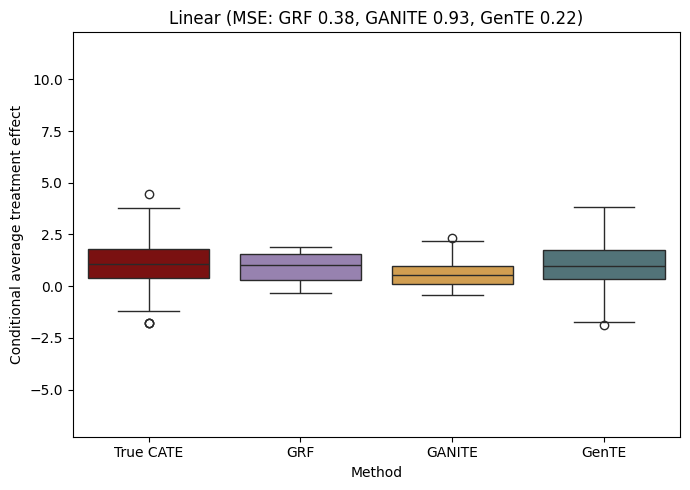

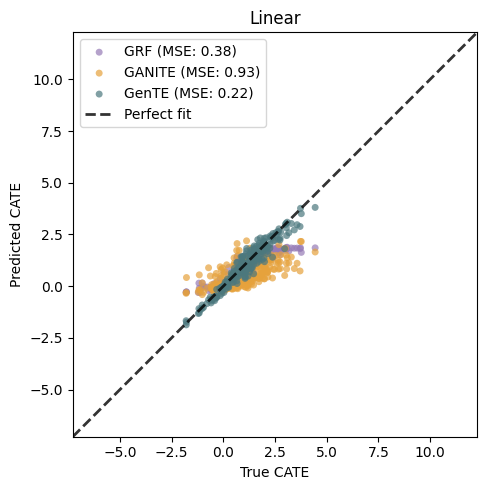

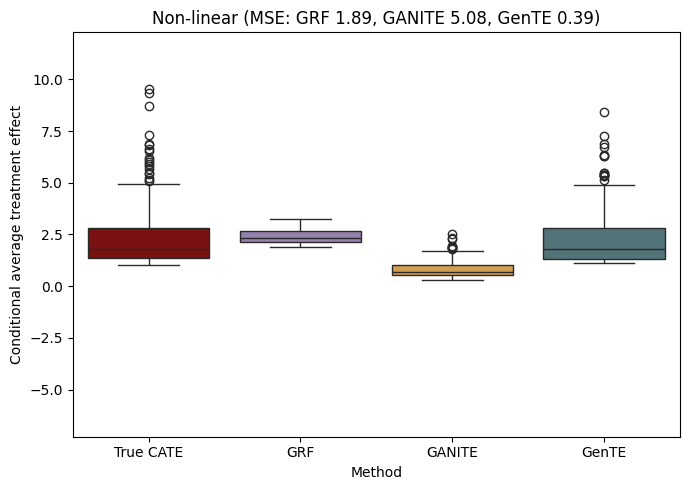

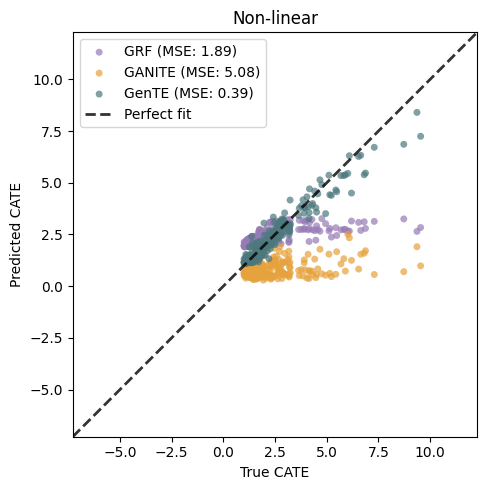

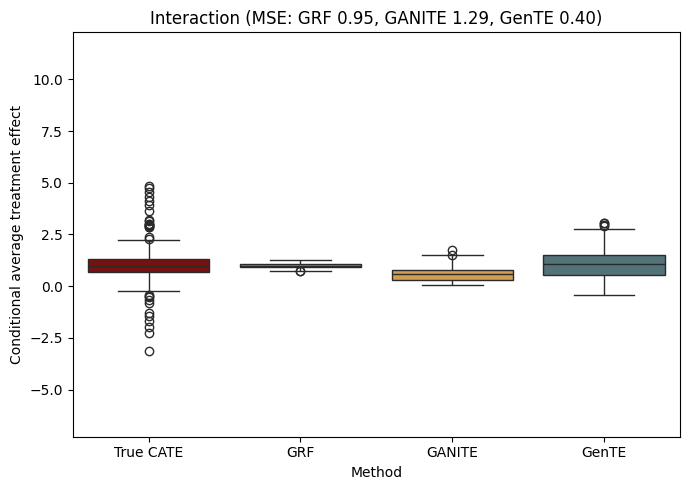

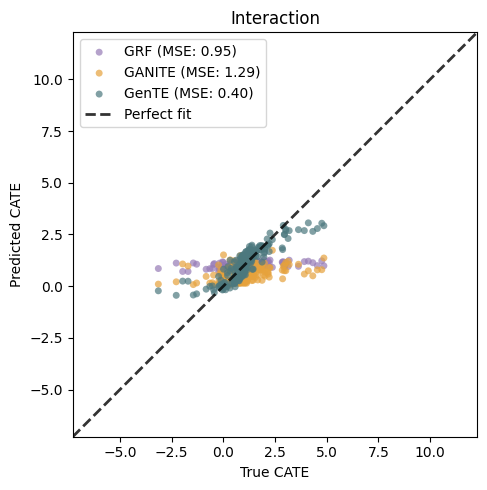

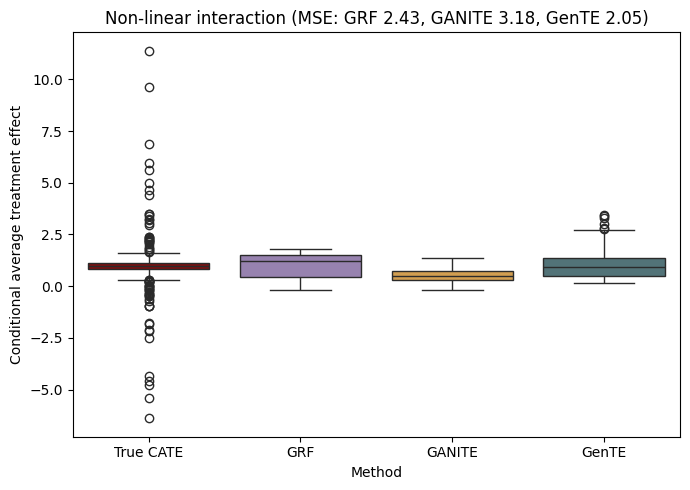

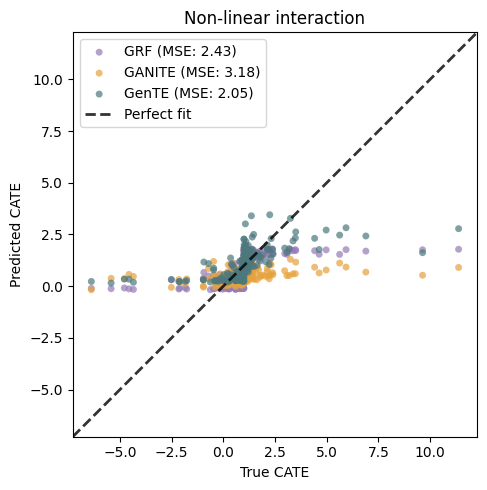

In [29]:

res = run_mc_simulations(n_mc=n_mc, plot_show=True)  

# Comparison to DML and GRF

In [2]:
importlib.reload(simulations)
from simulations import run_mse_table
#df_table = run_mse_table()                       # full run, saves the CSV
df_table = run_mse_table(n_mc=n_mc, 
                        save_table=True, 
                        results_dir='results_sims_mean',
                        verbose=True)   # test


linear                   S=  200 p= 2 (100 reps)
linear                   S=  200 p= 4 (100 reps)
linear                   S=  200 p= 8 (100 reps)
linear                   S=  500 p= 2 (100 reps)
linear                   S=  500 p= 4 (100 reps)
linear                   S=  500 p= 8 (100 reps)
linear                   S= 1000 p= 2 (100 reps)
linear                   S= 1000 p= 4 (100 reps)
linear                   S= 1000 p= 8 (100 reps)
non-linear               S=  200 p= 2 (100 reps)
non-linear               S=  200 p= 4 (100 reps)
non-linear               S=  200 p= 8 (100 reps)
non-linear               S=  500 p= 2 (100 reps)
non-linear               S=  500 p= 4 (100 reps)
non-linear               S=  500 p= 8 (100 reps)
non-linear               S= 1000 p= 2 (100 reps)
non-linear               S= 1000 p= 4 (100 reps)
non-linear               S= 1000 p= 8 (100 reps)
interaction              S=  200 p= 2 (100 reps)
interaction              S=  200 p= 4 (100 reps)
interaction         

# Comparison to GANITE

In [3]:
importlib.reload(simulations)
from simulations import run_mse_table_ganite
df_ganite = run_mse_table_ganite(
                        n_mc=n_mc, 
                        save_table=True, 
                        results_dir='results_sims_mean',
                        verbose=True)   # test
                        

linear                   S=  200 p= 2 (100 reps)
linear                   S=  200 p= 4 (100 reps)
linear                   S=  200 p= 8 (100 reps)
linear                   S=  500 p= 2 (100 reps)
linear                   S=  500 p= 4 (100 reps)
linear                   S=  500 p= 8 (100 reps)
linear                   S= 1000 p= 2 (100 reps)
linear                   S= 1000 p= 4 (100 reps)
linear                   S= 1000 p= 8 (100 reps)
non-linear               S=  200 p= 2 (100 reps)
non-linear               S=  200 p= 4 (100 reps)
non-linear               S=  200 p= 8 (100 reps)
non-linear               S=  500 p= 2 (100 reps)
non-linear               S=  500 p= 4 (100 reps)
non-linear               S=  500 p= 8 (100 reps)
non-linear               S= 1000 p= 2 (100 reps)
non-linear               S= 1000 p= 4 (100 reps)
non-linear               S= 1000 p= 8 (100 reps)
interaction              S=  200 p= 2 (100 reps)
interaction              S=  200 p= 4 (100 reps)
interaction         

In [4]:
# Generate LaTeX MSE table from simulation results (run after GRF+DML+GenTE and GANITE+GenTE cells)
import sys
sys.path.insert(0, 'src')
import mse_table_to_latex
importlib.reload(mse_table_to_latex)
from mse_table_to_latex import mse_table_to_latex, merge_grf_dml_gente_with_ganite

df_full = merge_grf_dml_gente_with_ganite(df_table, df_ganite)
#print(df_full)
mse_table_to_latex(df_full, outpath='results_sims_mean/mse_table_with_ganite.tex')


'\\begin{table}[H]\n\\centering\n\\caption{Mean squared error (MSE) of the generalised random forest (GRF), double machine learning based on XGBoost (DML-XGB), GANITE, and GenTE for different effect types, sample sizes $S$, and covariate dimensions $p$. Each cell reports the mean MSE with standard deviation in parentheses based on 100 Monte Carlo experiments. The last three columns report the average percent gain of GenTE relative to (i) GRF, (ii) DML-XGB, and (iii) GANITE, averaged over $p\\in\\{2,4,8\\}$ in each row.}\n\\resizebox{\\textwidth}{!}{%\n\\begin{tabular}{lrrrrrrrrrrrrrrr}\n\\toprule\n& \\multicolumn{3}{c}{GRF} & \\multicolumn{3}{c}{DML-XGB} & \\multicolumn{3}{c}{GANITE} & \\multicolumn{3}{c}{GenTE} & \\multicolumn{3}{c}{Avg.\\ \\% gain (GenTE)} \\\\\n\\cmidrule(lr){2-4}\\cmidrule(lr){5-7}\\cmidrule(lr){8-10}\\cmidrule(lr){11-13}\\cmidrule(lr){14-16}\nSample size\n& $p{=}2$ & $p{=}4$ & $p{=}8$\n& $p{=}2$ & $p{=}4$ & $p{=}8$\n& $p{=}2$ & $p{=}4$ & $p{=}8$\n& $p{=}2$ & $p{=}

# Does Joint Estimation Improve Upon Separately Estimating Conditional Densities?

We find substantial improvement of jointly estimating the parameters when compared to a T-learner with separate quantile-level estimates for each arm.

In [5]:
import simulations 
importlib.reload(simulations)
from simulations import run_mse_table_sep_joint
df_sep_joint = run_mse_table_sep_joint(
                        n_mc=n_mc, 
                        save_table=True, 
                        results_dir='results_sims_mean',
                        verbose=True)   # test
                        

linear                   S=  200 p= 2 (100 reps)
linear                   S=  200 p= 4 (100 reps)
linear                   S=  200 p= 8 (100 reps)
linear                   S=  500 p= 2 (100 reps)
linear                   S=  500 p= 4 (100 reps)
linear                   S=  500 p= 8 (100 reps)
linear                   S= 1000 p= 2 (100 reps)
linear                   S= 1000 p= 4 (100 reps)
linear                   S= 1000 p= 8 (100 reps)
non-linear               S=  200 p= 2 (100 reps)
non-linear               S=  200 p= 4 (100 reps)
non-linear               S=  200 p= 8 (100 reps)
non-linear               S=  500 p= 2 (100 reps)
non-linear               S=  500 p= 4 (100 reps)
non-linear               S=  500 p= 8 (100 reps)
non-linear               S= 1000 p= 2 (100 reps)
non-linear               S= 1000 p= 4 (100 reps)
non-linear               S= 1000 p= 8 (100 reps)
interaction              S=  200 p= 2 (100 reps)
interaction              S=  200 p= 4 (100 reps)
interaction         

In [6]:
import importlib
import sys
sys.path.insert(0, 'results_sims_mean')
import mse_table_to_latex
importlib.reload(mse_table_to_latex)
from mse_table_to_latex import gente_sep_joint_to_latex

tex = gente_sep_joint_to_latex(
    df_sep_joint,
    outpath='results_sims_mean/mse_table_gente_sep_joint.tex',
)
print(tex)


\begin{table}[H]
\centering
\caption{Mean squared error of GenTE with separate treated/control quantile functions versus joint estimation, by effect type, sample size $n$, and covariate dimension $p$. Each cell is the mean MSE (standard deviation in parentheses) over 100 Monte Carlo replications.}
\label{tab:gente_sep_joint}
\resizebox{\textwidth}{!}{%
\begin{tabular}{lrrrrrr}
\toprule
& \multicolumn{3}{c}{GenTE (separate)} & \multicolumn{3}{c}{GenTE (joint)} \\
\cmidrule(lr){2-4}\cmidrule(lr){5-7}
Sample size & $p{=}2$ & $p{=}4$ & $p{=}8$ & $p{=}2$ & $p{=}4$ & $p{=}8$ \\
\midrule
\multicolumn{7}{l}{Linear} \\
\midrule
200 & 0.722 & 1.124 & 1.151 & 0.107 & 0.345 & 0.712 \\
  & (0.163) & (0.335) & (0.330) & (0.067) & (0.165) & (0.380) \\
500 & 0.676 & 1.068 & 1.124 & 0.064 & 0.222 & 0.409 \\
  & (0.122) & (0.200) & (0.145) & (0.046) & (0.138) & (0.232) \\
1000 & 0.680 & 1.054 & 1.115 & 0.053 & 0.170 & 0.302 \\
  & (0.111) & (0.185) & (0.142) & (0.046) & (0.101) & (0.147) \\
\addlinespac

# Alternative Treatment Assignment Mechanisms

RCT                (100 reps)
  GenTE 5.2456 ± 1.5972
Linear logit       (100 reps)
  GenTE 5.0975 ± 1.5411
Nonlinear logit    (100 reps)
  GenTE 4.9928 ± 1.3334
Trigonometric      (100 reps)
  GenTE 5.2062 ± 1.7499

saved results_sims_mean/df_table_assignments.csv
saved results_sims_mean/mse_records_assignments.csv
saved results_sims_mean/box_assignment_mse.pdf
saved results_sims_mean/box_assignment_mse.png


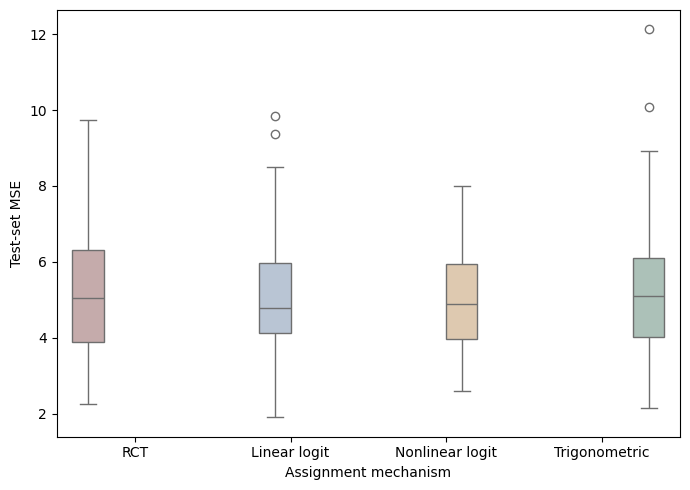


RCT: GenTE 5.2456 ± 1.5972
Linear logit: GenTE 5.0975 ± 1.5411
Nonlinear logit: GenTE 4.9928 ± 1.3334
Trigonometric: GenTE 5.2062 ± 1.7499


In [7]:
import simulations 
importlib.reload(simulations)
from simulations import run_assignment_robustness

output = run_assignment_robustness(
    n_mc=n_mc,
    # ---- output ---------------------------------------------------
    results_dir='results_sims_mean',
    table_name='df_table_assignments',
    records_name='mse_records_assignments',
    plot_name='box_assignment_mse',
    save_table=True,
    save_plots=True,
    plot_show=True,
)


## Robustness to Noise

SNR = 0.1   (100 reps)
  GenTE 55.0738 ± 31.5315
SNR = 0.5   (100 reps)
  GenTE 17.8150 ± 6.9223
SNR = 1     (100 reps)
  GenTE 11.7152 ± 3.9664
SNR = 2     (100 reps)
  GenTE 8.5286 ± 3.0303
SNR = 3     (100 reps)
  GenTE 7.2351 ± 2.3350

saved results_sims_mean/df_table_snr.csv
saved results_sims_mean/mse_records_snr.csv
saved results_sims_mean/line_snr_mse.pdf
saved results_sims_mean/line_snr_mse.png


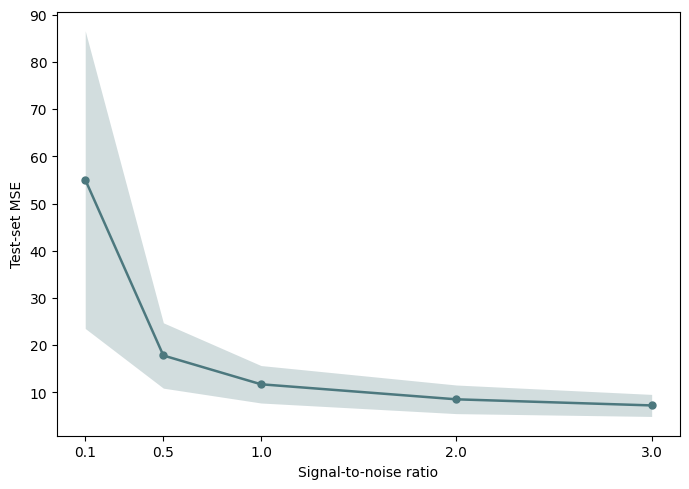


SNR 0.1: GenTE 55.0738 ± 31.5315
SNR 0.5: GenTE 17.8150 ± 6.9223
SNR 1: GenTE 11.7152 ± 3.9664
SNR 2: GenTE 8.5286 ± 3.0303
SNR 3: GenTE 7.2351 ± 2.3350


In [8]:
import simulations 
importlib.reload(simulations)
from simulations import run_snr_robustness


results_noise  = run_snr_robustness(
    n_mc = n_mc,
    results_dir='results_sims_mean',
    table_name='df_table_snr',
    records_name='mse_records_snr',
    plot_name='line_snr_mse',
    save_table=True,
    save_plots=True,
    plot_show=True
)
